In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\tanay\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\9325B14D33E8D654C1151D686982F8DC4DF31304\transfers\2026-32\Toyota.csv")
df

,Unnamed: 0,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,0,13500,23.0,46986,Diesel,90,1.0,0,2000,three,1165
1,1,13750,23.0,72937,Diesel,90,1.0,0,2000,3,1165
2,2,13950,24.0,41711,Diesel,90,NaN,0,2000,3,1165
3,3,14950,26.0,48000,Diesel,90,0.0,0,2000,3,1165
4,4,13750,30.0,38500,Diesel,90,0.0,0,2000,3,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,1431,7500,NaN,20544,Petrol,86,1.0,0,1300,3,1025
1432,1432,10845,72.0,??,Petrol,86,0.0,0,1300,3,1015
1433,1433,8500,NaN,17016,Petrol,86,0.0,0,1300,3,1015
1434,1434,7250,70.0,??,NaN,86,1.0,0,1300,3,1015


In [3]:
df.isnull().sum()

Unnamed: 0      0
Price           0
Age           100
KM              0
FuelType      100
HP              0
MetColor      150
Automatic       0
CC              0
Doors           0
Weight          0
dtype: int64

In [5]:
nums = []
for col in df.columns:
    if df[col].dtype == "int64" or df[col].dtype == "float64":
        nums.append(col)
print(nums)
        

['Unnamed: 0', 'Price', 'Age', 'MetColor', 'Automatic', 'CC', 'Weight']


In [22]:
nums = ['Unnamed: 0', 'Price', 'Age', 'MetColor', 'Automatic', 'CC', 'Weight','KM','Doors']
for i in nums:
    df[i] = pd.to_numeric(df[i],errors = "coerce")
    


KeyError: 'Unnamed: 0'

In [7]:
for i in nums:
    df[i] = df[i].fillna(df[i].median())

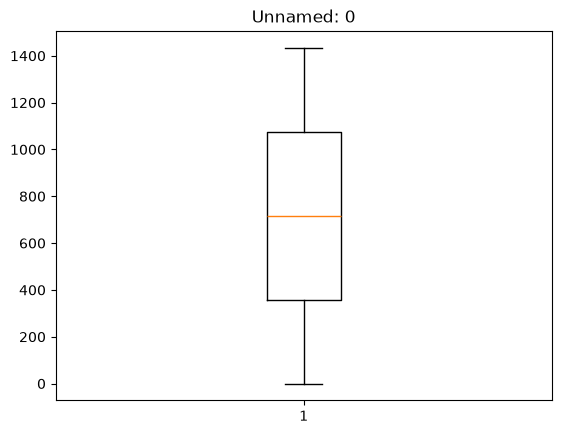

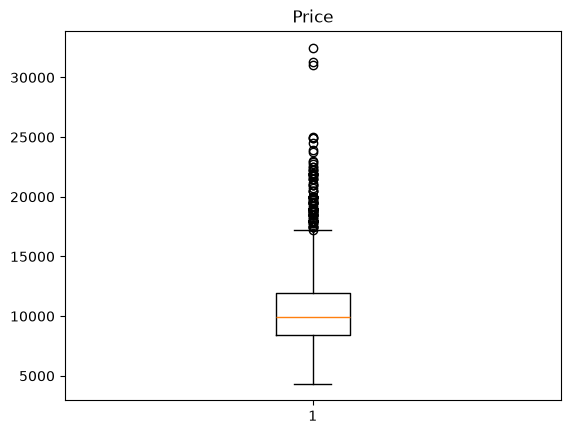

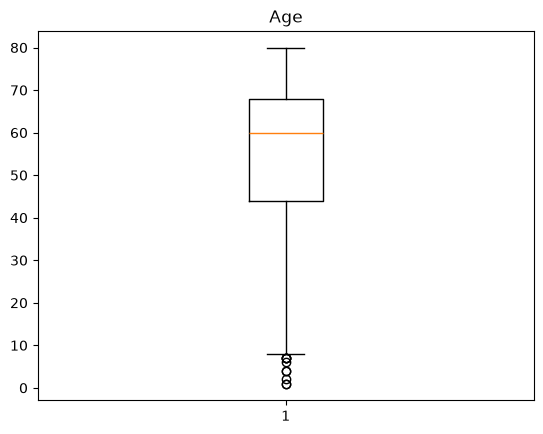

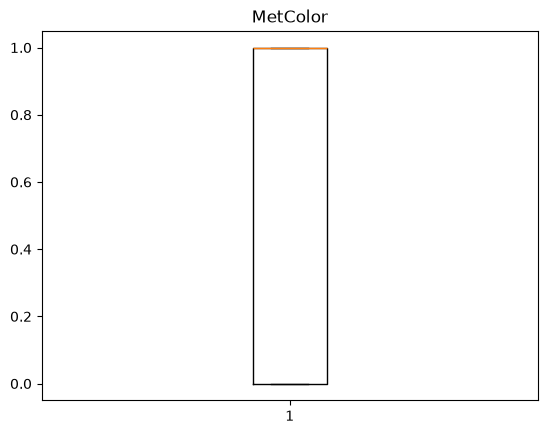

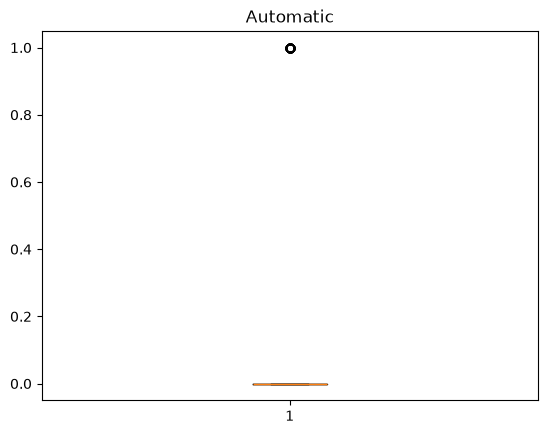

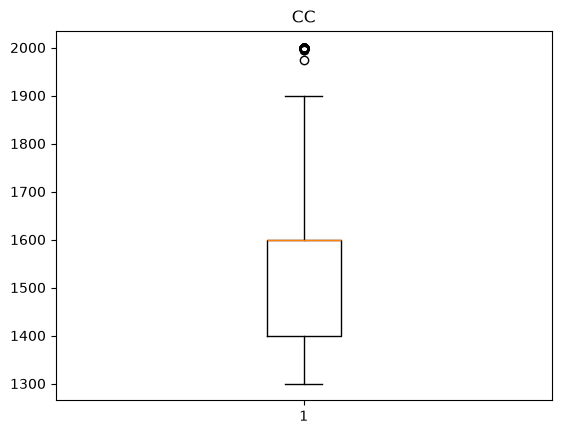

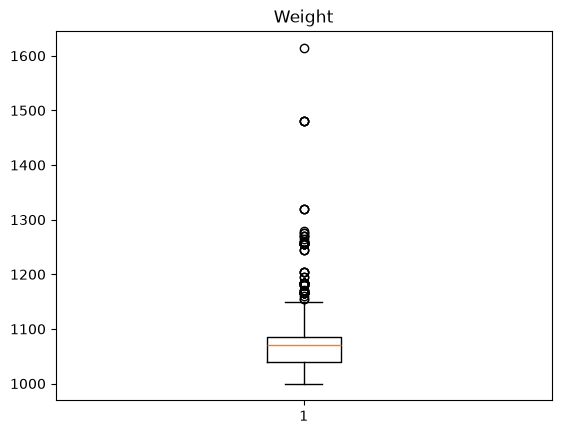

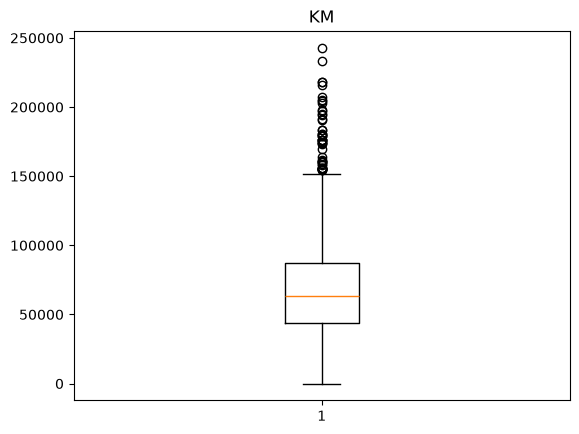

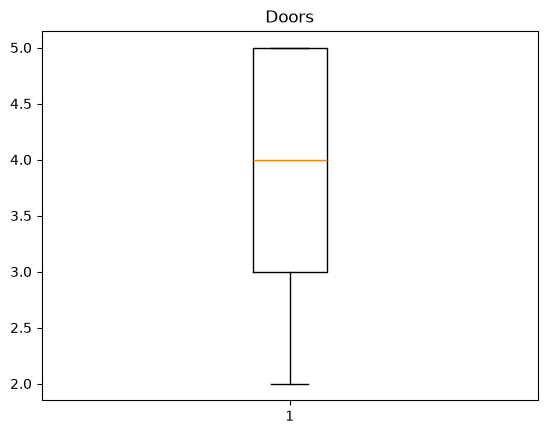

In [8]:
import matplotlib.pyplot as plt
for i in nums:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [12]:
for i in nums:
    if i in df.columns:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - IQR*1.5
        upper = Q3 + IQR*1.5
        df[i] = df[i].astype(float)
        median = df[i].median()
        
        df.loc[(df[i]<lower) | (df[i]>upper),i]=median

In [14]:
print(df['Price'].describe())
print(df['Price'].nunique())

count     1436.000000
mean      9941.440808
std       2272.786376
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      10950.000000
max      17200.000000
Name: Price, dtype: float64
190


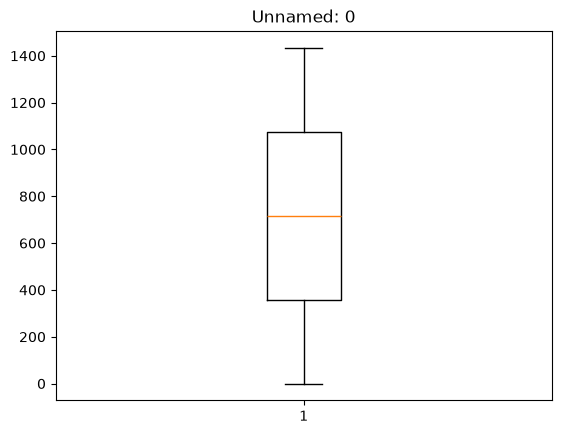

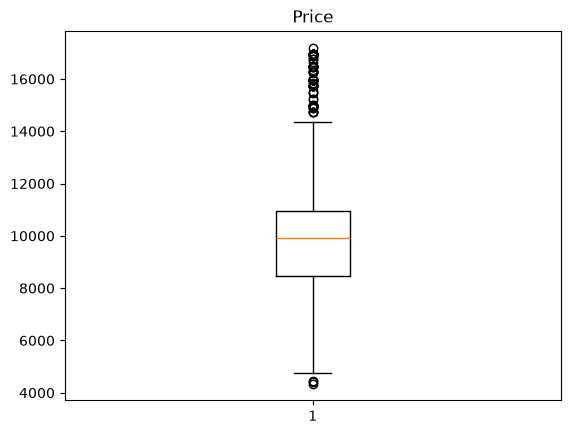

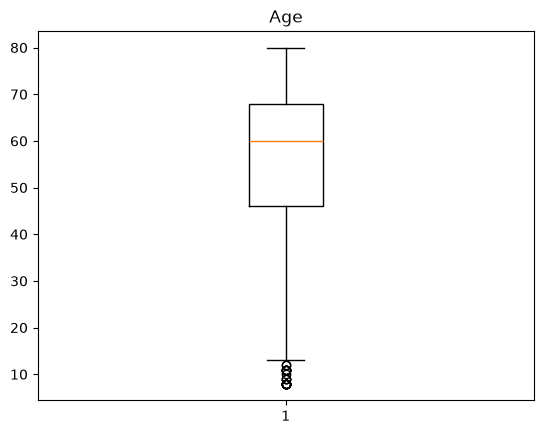

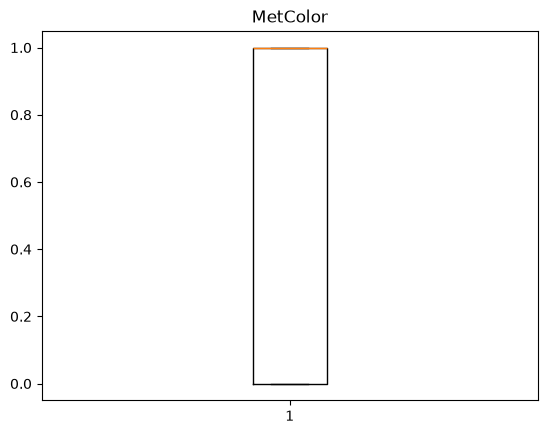

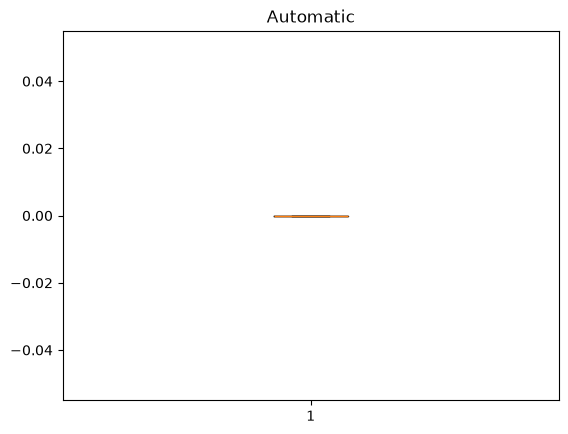

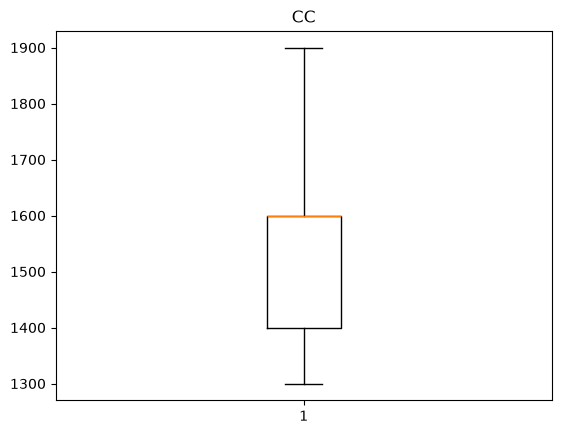

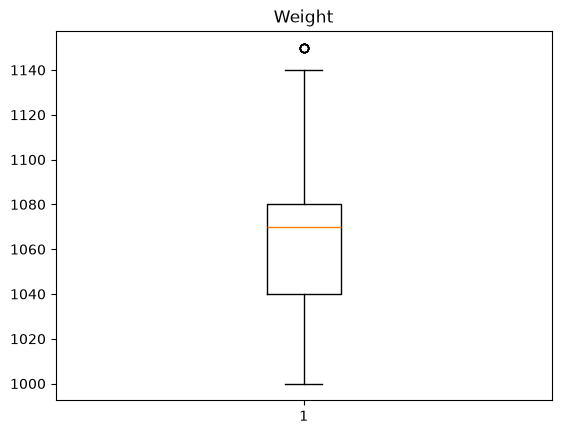

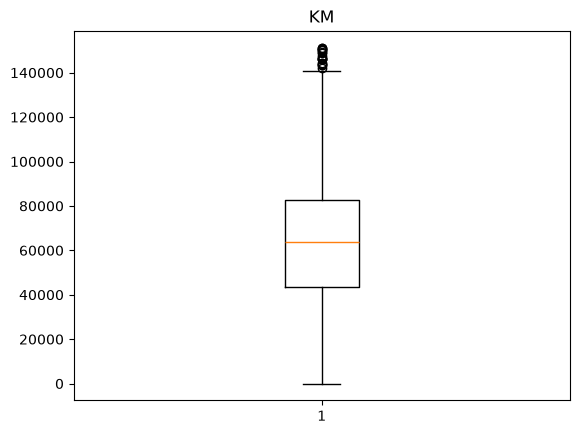

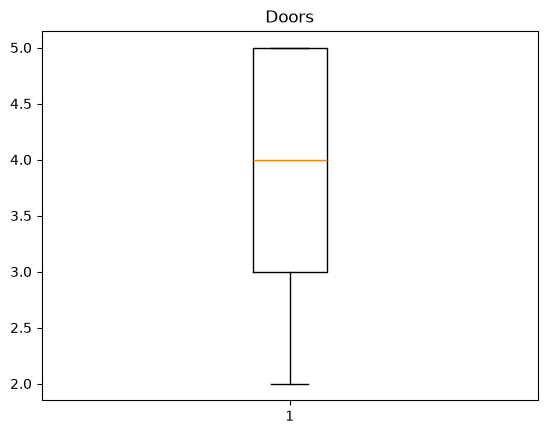

In [15]:
for i in nums:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [25]:
df.drop("Unnamed: 0", axis=1, inplace=True)
df.drop("FuelType",axis=1,inplace=True)
df

KeyError: "['Unnamed: 0'] not found in axis"

In [37]:
df.drop("Automatic",axis =1,inplace=True)


KeyError: "['Automatic'] not found in axis"

In [ ]:
df

In [38]:
df.drop("HP",axis=1,inplace=True)

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size = 0.2,random_state = 42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [40]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
lr.fit(x_train,y_train)

ValueError: could not convert string to float: '????'